# CS/DS 3262 Final Project — TikTok Binge-Session Classifier

**Target:** Binary label `binge` per session (top-10% daily volume AND ≥ 2× user median)  
**Unit:** Session — contiguous events separated by < 30-minute gaps  
**Data:** Personal TikTok data export (`user_data_tiktok.json`)  
**Models:** Logistic Regression · Random Forest · Gradient Boosted Trees  
**Evaluation:** 5-fold stratified CV — Accuracy, F1, Precision, Recall, AUC-ROC

## 1. Imports

In [1]:
import json
import zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from datetime import datetime, timedelta
from pathlib import Path

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    roc_auc_score, roc_curve, confusion_matrix, ConfusionMatrixDisplay,
    make_scorer
)
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
SEED = 42

## 2. Load Data

In [2]:
ZIP_PATH = Path('TikTok_Data_1776821537.zip')

with zipfile.ZipFile(ZIP_PATH) as z:
    with z.open('user_data_tiktok.json') as f:
        data = json.load(f)

act = data['Your Activity']
laf = data['Likes and Favorites']
print('Export loaded.')

Export loaded.


## 3. Parse Events

In [3]:
DATE_FMT = '%Y-%m-%d %H:%M:%S'

def parse_date(s):
    try:
        return datetime.strptime((s or '').strip(), DATE_FMT)
    except Exception:
        return None

def collect_events():
    rows = []
    def add(source, primitive, records, date_key='Date'):
        for r in records:
            ts = parse_date(r.get(date_key) or r.get('date', ''))
            if ts:
                rows.append({'ts': ts, 'source': source, 'primitive': primitive})

    add('watch',          'attention',  act.get('Watch History',  {}).get('VideoList', []))
    add('search',         'intent',     act.get('Searches',       {}).get('SearchList', []))
    add('share',          'social',     act.get('Share History',  {}).get('ShareHistoryList', []))
    add('repost',         'social',     act.get('Reposts',        {}).get('RepostList', []))
    add('comment',        'social',     data.get('Comment', {}).get('Comments', {}).get('CommentsList', []))
    add('like',           'preference', laf.get('Likes',           {}).get('ItemFavoriteList', []), date_key='date')
    add('favorite_video', 'preference', laf.get('Favorite Videos', {}).get('FavoriteVideoList', []))
    add('favorite_sound', 'preference', laf.get('Favorite Sounds', {}).get('FavoriteSoundList', []))

    return pd.DataFrame(rows).sort_values('ts').reset_index(drop=True)

events = collect_events()
print(f'Total dated events: {len(events):,}')
events['primitive'].value_counts()

Total dated events: 85,494


primitive
attention     60541
social        11980
preference    11512
intent         1461
Name: count, dtype: int64

## 4. Session Segmentation

In [4]:
SESSION_GAP = timedelta(minutes=30)

def assign_sessions(df):
    df = df.copy().sort_values('ts').reset_index(drop=True)
    sids = [0]
    for i in range(1, len(df)):
        sids.append(sids[-1] + (1 if df.loc[i, 'ts'] - df.loc[i-1, 'ts'] > SESSION_GAP else 0))
    df['session_id'] = sids
    return df

events = assign_sessions(events)
print(f'Total sessions: {events["session_id"].nunique():,}')

Total sessions: 7,301


## 5. Feature Extraction

In [5]:
def extract_features(grp):
    n        = len(grp)
    duration = (grp['ts'].max() - grp['ts'].min()).total_seconds() / 60.0
    start    = grp['ts'].min()

    # Search → watch cascade count
    cascade, last_search = 0, False
    for src in grp.sort_values('ts')['source']:
        if src == 'search':
            last_search = True
        elif src == 'watch' and last_search:
            cascade += 1
            last_search = False

    return {
        'session_id':    grp['session_id'].iloc[0],
        'date':          start.date(),
        'event_count':   n,
        'duration_min':  duration,
        'peak_epm':      round(n / max(duration, 1.0), 4),
        'watch_share':   (grp['primitive'] == 'attention').mean(),
        'search_share':  (grp['source']    == 'search').mean(),
        'social_share':  (grp['primitive'] == 'social').mean(),
        'pref_share':    (grp['primitive'] == 'preference').mean(),
        'cascade_count': cascade,
        'hour_of_day':   start.hour,
        'day_of_week':   start.weekday(),
        'has_search':    int((grp['source'] == 'search').any()),
        'has_social':    int((grp['primitive'] == 'social').any()),
    }

sessions = pd.DataFrame([extract_features(g) for _, g in events.groupby('session_id')])
sessions[['event_count', 'duration_min', 'peak_epm']].describe().round(2)

,event_count,duration_min,peak_epm
count,7301.00,7301.00,7301.00
mean,11.71,14.21,1.13
std,43.66,22.36,1.47
min,1.00,0.00,0.06
25%,1.00,0.00,0.25
50%,2.00,4.23,1.00
75%,5.00,20.67,1.00
max,1226.00,332.03,19.36


## 6. Binge Label

Daily median: 9 events | 90th pct threshold: 36 events
Binge days: 213 / 2122 (10.0%)
Binge sessions: 1,121 / 7,301 (15.4%)


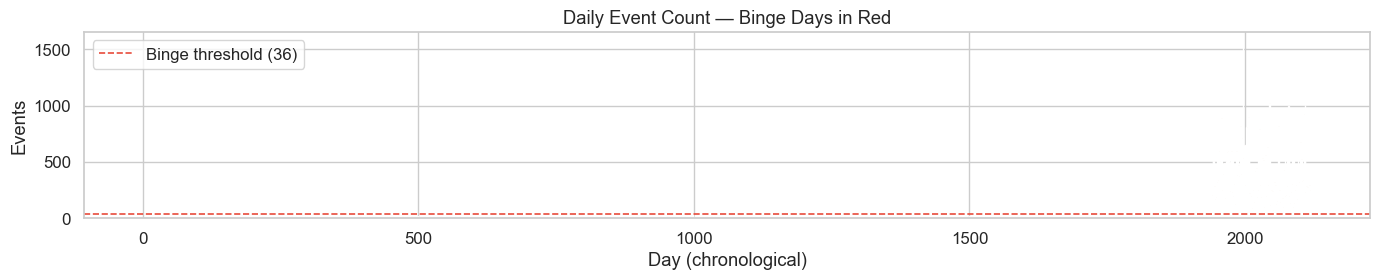

In [6]:
daily_counts     = events.groupby(events['ts'].dt.date).size()
top10_threshold  = daily_counts.quantile(0.90)
median_daily     = daily_counts.median()

binge_days = set(daily_counts[
    (daily_counts >= top10_threshold) & (daily_counts >= 2 * median_daily)
].index)

sessions['binge'] = sessions['date'].apply(lambda d: int(d in binge_days))

print(f'Daily median: {median_daily:.0f} events | 90th pct threshold: {top10_threshold:.0f} events')
print(f'Binge days: {len(binge_days)} / {len(daily_counts)} ({len(binge_days)/len(daily_counts):.1%})')
print(f'Binge sessions: {sessions["binge"].sum():,} / {len(sessions):,} ({sessions["binge"].mean():.1%})')

# Daily activity with binge days highlighted
fig, ax = plt.subplots(figsize=(14, 3))
colors = ['#e74c3c' if d in binge_days else '#95a5a6' for d in daily_counts.index]
ax.bar(range(len(daily_counts)), daily_counts.values, color=colors, width=1.0)
ax.axhline(top10_threshold, color='#e74c3c', linestyle='--', linewidth=1.2, label=f'Binge threshold ({top10_threshold:.0f})')
ax.set_xlabel('Day (chronological)')
ax.set_ylabel('Events')
ax.set_title('Daily Event Count — Binge Days in Red')
ax.legend()
plt.tight_layout()
plt.savefig('plot_daily_activity.png', dpi=150)
plt.show()

## 7. ML Pipeline Setup

In [7]:
FEATURE_COLS = [
    'event_count', 'duration_min', 'peak_epm',
    'watch_share', 'search_share', 'social_share', 'pref_share',
    'cascade_count', 'hour_of_day', 'day_of_week',
    'has_search', 'has_social',
]

X = sessions[FEATURE_COLS].values
y = sessions['binge'].values

def auc_scorer(clf, X, y):
    return roc_auc_score(y, clf.predict_proba(X)[:, 1])

scoring = {
    'accuracy':  make_scorer(accuracy_score),
    'f1':        make_scorer(f1_score, zero_division=0),
    'precision': make_scorer(precision_score, zero_division=0),
    'recall':    make_scorer(recall_score, zero_division=0),
    'roc_auc':   auc_scorer,
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

models = {
    'Logistic Regression': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(max_iter=1000, class_weight='balanced', random_state=SEED)),
    ]),
    'Random Forest': Pipeline([
        ('clf', RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=SEED)),
    ]),
    'Gradient Boosted Trees': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', GradientBoostingClassifier(n_estimators=200, learning_rate=0.05, random_state=SEED)),
    ]),
}

print('Models defined. Running 5-fold CV...')

Models defined. Running 5-fold CV...


## 8. Cross-Validation Results

In [8]:
cv_results = {}
for name, model in models.items():
    cv_results[name] = cross_validate(model, X, y, cv=cv, scoring=scoring, n_jobs=-1)
    print(f'  {name} done.')

metrics = ['accuracy', 'f1', 'precision', 'recall', 'roc_auc']
summary = pd.DataFrame({
    name: {m: cv_results[name][f'test_{m}'].mean() for m in metrics}
    for name in models
}).T.round(3)

summary.columns = ['Accuracy', 'F1', 'Precision', 'Recall', 'AUC']
summary

  Logistic Regression done.


  Random Forest done.


  Gradient Boosted Trees done.


,Accuracy,F1,Precision,Recall,AUC
Logistic Regression,0.965,0.881,0.933,0.836,0.943
Random Forest,0.965,0.876,0.955,0.810,0.934
Gradient Boosted Trees,0.968,0.886,0.973,0.814,0.945


## 9. Plot: Metric Comparison

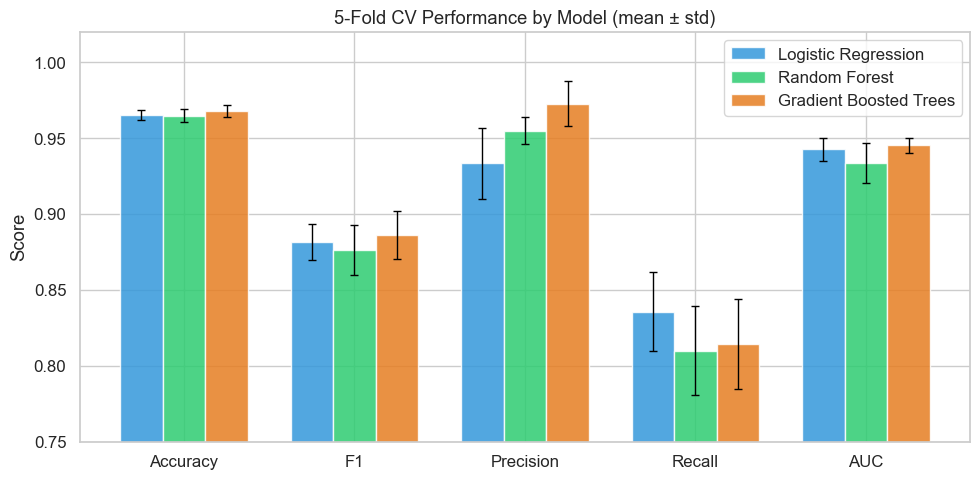

In [9]:
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(metrics))
width = 0.25
colors = ['#3498db', '#2ecc71', '#e67e22']
labels = list(models.keys())

for i, (name, color) in enumerate(zip(labels, colors)):
    means = [cv_results[name][f'test_{m}'].mean() for m in metrics]
    stds  = [cv_results[name][f'test_{m}'].std()  for m in metrics]
    bars  = ax.bar(x + i * width, means, width, label=name, color=color, alpha=0.85)
    ax.errorbar(x + i * width, means, yerr=stds, fmt='none', color='black', capsize=3, linewidth=1)

ax.set_xticks(x + width)
ax.set_xticklabels(['Accuracy', 'F1', 'Precision', 'Recall', 'AUC'])
ax.set_ylim(0.75, 1.02)
ax.set_ylabel('Score')
ax.set_title('5-Fold CV Performance by Model (mean ± std)')
ax.legend()
plt.tight_layout()
plt.savefig('plot_metric_comparison.png', dpi=150)
plt.show()

## 10. Plot: ROC Curves

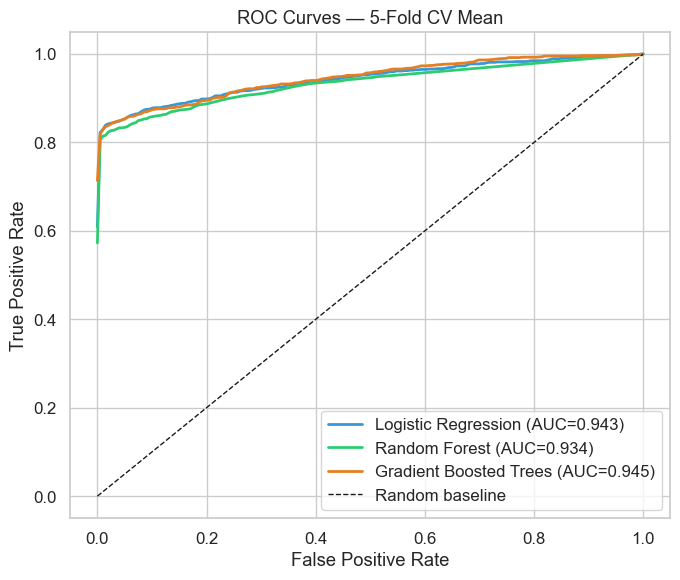

In [10]:
fig, ax = plt.subplots(figsize=(7, 6))
colors = ['#3498db', '#2ecc71', '#e67e22']

for (name, model), color in zip(models.items(), colors):
    fold_fprs, fold_tprs = [], []
    mean_fpr = np.linspace(0, 1, 200)
    for train_idx, test_idx in cv.split(X, y):
        model.fit(X[train_idx], y[train_idx])
        proba = model.predict_proba(X[test_idx])[:, 1]
        fpr, tpr, _ = roc_curve(y[test_idx], proba)
        fold_tprs.append(np.interp(mean_fpr, fpr, tpr))
    mean_tpr = np.mean(fold_tprs, axis=0)
    auc = cv_results[name]['test_roc_auc'].mean()
    ax.plot(mean_fpr, mean_tpr, label=f'{name} (AUC={auc:.3f})', color=color, linewidth=2)

ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random baseline')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves — 5-Fold CV Mean')
ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig('plot_roc_curves.png', dpi=150)
plt.show()

## 11. Plot: Confusion Matrices

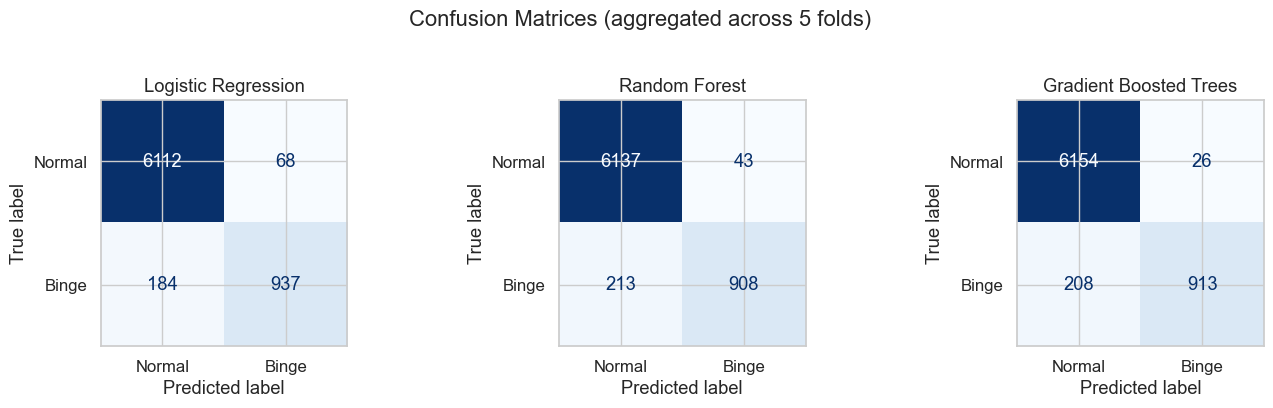

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, (name, model) in zip(axes, models.items()):
    all_preds, all_true = [], []
    for train_idx, test_idx in cv.split(X, y):
        model.fit(X[train_idx], y[train_idx])
        all_preds.extend(model.predict(X[test_idx]))
        all_true.extend(y[test_idx])
    cm = confusion_matrix(all_true, all_preds)
    disp = ConfusionMatrixDisplay(cm, display_labels=['Normal', 'Binge'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(name)

plt.suptitle('Confusion Matrices (aggregated across 5 folds)', y=1.02)
plt.tight_layout()
plt.savefig('plot_confusion_matrices.png', dpi=150)
plt.show()

## 12. Plot: Feature Importance (Random Forest)

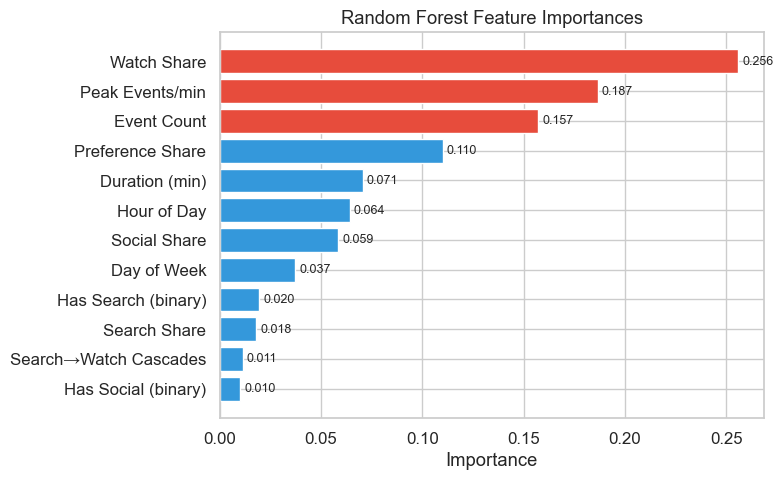

In [12]:
rf_model = models['Random Forest']
rf_model.fit(X, y)
importances = rf_model.named_steps['clf'].feature_importances_
fi = pd.Series(importances, index=FEATURE_COLS).sort_values()

FEATURE_LABELS = {
    'event_count':   'Event Count',
    'duration_min':  'Duration (min)',
    'peak_epm':      'Peak Events/min',
    'watch_share':   'Watch Share',
    'search_share':  'Search Share',
    'social_share':  'Social Share',
    'pref_share':    'Preference Share',
    'cascade_count': 'Search→Watch Cascades',
    'hour_of_day':   'Hour of Day',
    'day_of_week':   'Day of Week',
    'has_search':    'Has Search (binary)',
    'has_social':    'Has Social (binary)',
}

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.barh(
    [FEATURE_LABELS[f] for f in fi.index],
    fi.values,
    color=['#e74c3c' if v > 0.15 else '#3498db' for v in fi.values]
)
ax.set_xlabel('Importance')
ax.set_title('Random Forest Feature Importances')
for bar, val in zip(bars, fi.values):
    ax.text(val + 0.002, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=9)
plt.tight_layout()
plt.savefig('plot_feature_importance.png', dpi=150)
plt.show()

## 13. Per-Fold Detail Table

In [13]:
for name in models:
    print(f'\n── {name} ──')
    rows = []
    for m in metrics:
        vals = cv_results[name][f'test_{m}']
        rows.append({'Metric': m.capitalize(), **{f'Fold {i+1}': round(v, 3) for i, v in enumerate(vals)},
                     'Mean': round(vals.mean(), 3), 'Std': round(vals.std(), 3)})
    display(pd.DataFrame(rows).set_index('Metric'))


── Logistic Regression ──


,Fold 1,Fold 2,Fold 3,Fold 4,Fold 5,Mean,Std
Metric,,,,,,,
Accuracy,0.969,0.962,0.968,0.967,0.962,0.965,0.003
F1,0.894,0.863,0.889,0.888,0.872,0.881,0.012
Precision,0.924,0.952,0.964,0.931,0.896,0.933,0.023
Recall,0.867,0.790,0.826,0.848,0.848,0.836,0.026
Roc_auc,0.952,0.930,0.941,0.942,0.948,0.943,0.007



── Random Forest ──


,Fold 1,Fold 2,Fold 3,Fold 4,Fold 5,Mean,Std
Metric,,,,,,,
Accuracy,0.966,0.958,0.964,0.971,0.966,0.965,0.004
F1,0.882,0.849,0.870,0.898,0.882,0.876,0.016
Precision,0.940,0.955,0.967,0.959,0.953,0.955,0.009
Recall,0.831,0.763,0.790,0.844,0.821,0.810,0.029
Roc_auc,0.954,0.913,0.932,0.935,0.935,0.934,0.013



── Gradient Boosted Trees ──


,Fold 1,Fold 2,Fold 3,Fold 4,Fold 5,Mean,Std
Metric,,,,,,,
Accuracy,0.971,0.964,0.965,0.974,0.966,0.968,0.004
F1,0.900,0.866,0.875,0.909,0.880,0.886,0.016
Precision,0.969,0.994,0.973,0.979,0.948,0.973,0.015
Recall,0.840,0.768,0.795,0.848,0.821,0.814,0.030
Roc_auc,0.951,0.939,0.940,0.950,0.946,0.945,0.005
